In [62]:
import pandas as pd
import numpy as np

In [63]:
df = pd.read_csv(r'C:\Users\HP\Desktop\anuska_internship\02_Project\archive (1)\01_Data\StudentsPerformance.csv')

In [64]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [65]:
df.shape

(1000, 8)

In [66]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [67]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df.drop_duplicates(inplace=True)

In [70]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
#5-Line Dataset Summary
##The dataset contains student demographic information along with mathematics, reading, and writing scores.
#It includes categorical variables such as gender, race/ethnicity, parental education, lunch type, and test preparation status.
#The dataset contains 1000 student records with 8 features.
#There are no missing values, and duplicate records (if any) were removed during data cleaning.
#This dataset can be used to analyze how demographic and educational factors influence academic performance.

In [71]:
df['total_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
)

In [ ]:
df['average_score'] = df['total_score'] / 3

In [ ]:
parent_scores = df.groupby('parental level of education')[
    ['math score','reading score','writing score','average_score']
].mean().sort_values(by='average_score', ascending=False)

parent_scores.round(2)

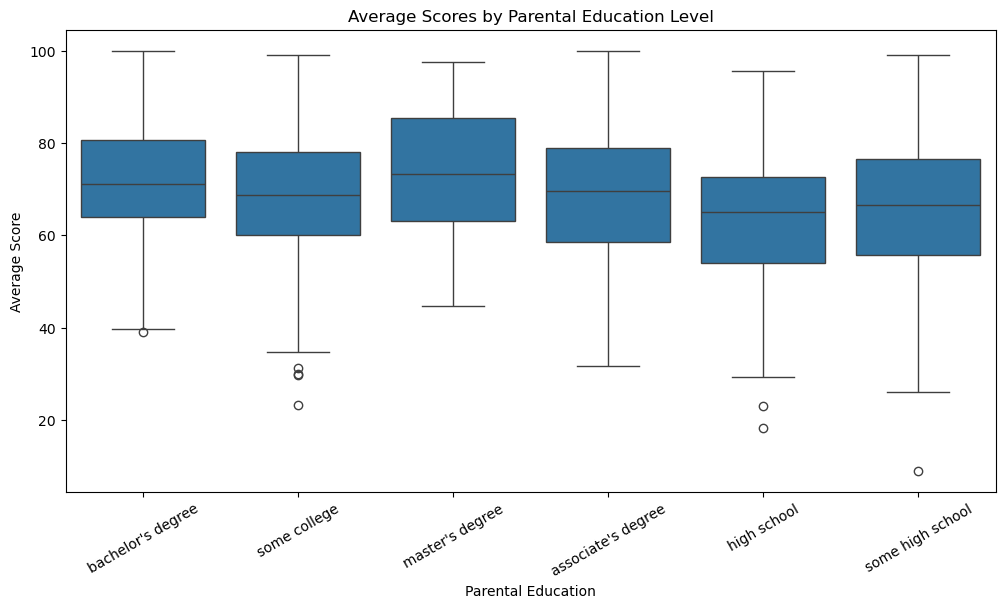

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='parental level of education',
    y='average_score'
)

plt.xticks(rotation=30)
plt.title("Average Scores by Parental Education Level")
plt.xlabel("Parental Education")
plt.ylabel("Average Score")

plt.show()

#Interpretation#
Students whose parents have Master's and Bachelor's degrees generally achieve higher average scores.
Students whose parents have High School or Some High School education tend to have lower scores.

In [75]:
prep_scores = df.groupby('test preparation course')[
    ['math score','reading score','writing score','average_score']
].mean()

prep_scores.round(2)

,math score,reading score,writing score,average_score
test preparation course,,,,
completed,69.70,73.89,74.42,72.67
none,64.08,66.53,64.50,65.04


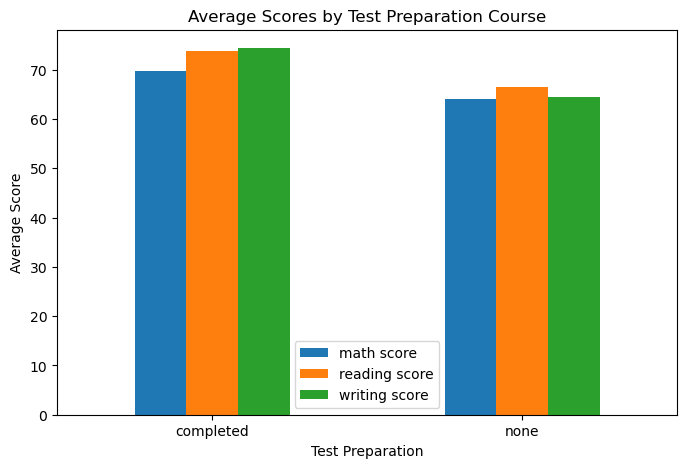

In [76]:
prep_scores[['math score','reading score','writing score']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Scores by Test Preparation Course")
plt.xlabel("Test Preparation")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.show()

Interpretation
Students who completed the test preparation course consistently score higher across all three subjects.
The improvement is particularly noticeable in reading and writing.

In [77]:
corr = df[
    ['math score','reading score','writing score']
].corr()

corr

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


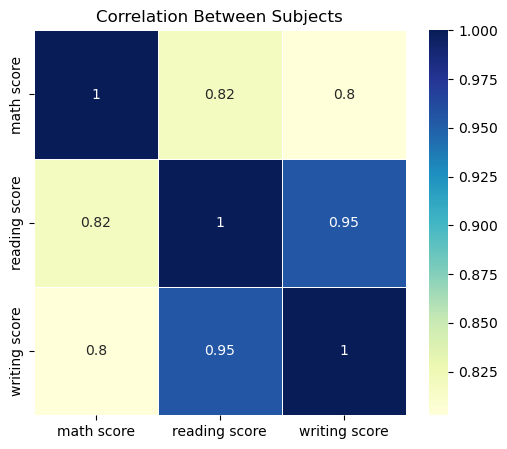

In [78]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Correlation Between Subjects")

plt.show()

Interpretation
Reading and writing have a very strong positive correlation.
Mathematics also has a strong positive relationship with both reading and writing.
Students performing well in one subject tend to perform well in the others.

In [79]:
gender_scores = df.groupby('gender')[
    ['math score','reading score','writing score']
].mean()

gender_scores.round(2)

,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


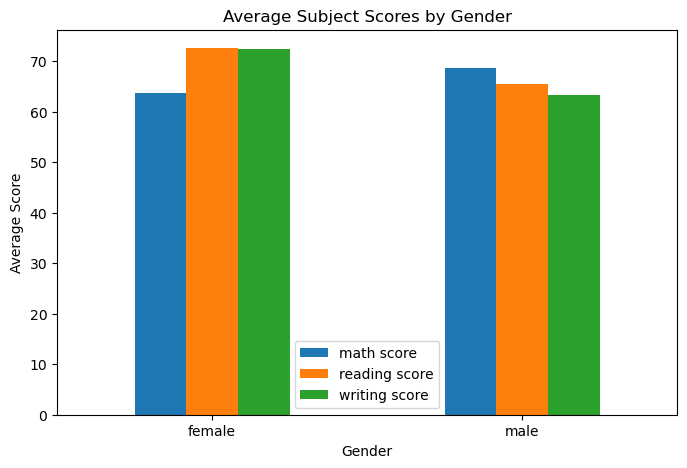

In [80]:
gender_scores.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Subject Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")

plt.xticks(rotation=0)

plt.show()

Interpretation
Male students generally perform slightly better in Mathematics.
Female students outperform male students in Reading and Writing.

In [81]:
df['total_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
)

In [82]:
df['total_score'].describe()

count    1000.000000
mean      203.312000
std        42.771978
min        27.000000
25%       175.000000
50%       205.000000
75%       233.000000
max       300.000000
Name: total_score, dtype: float64

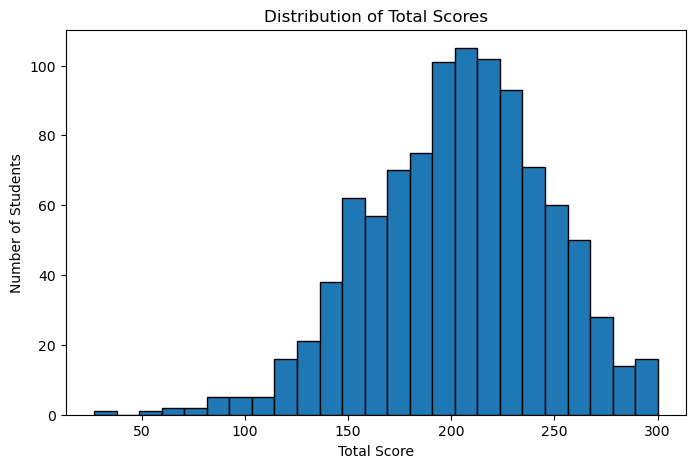

In [83]:
plt.figure(figsize=(8,5))

plt.hist(
    df['total_score'],
    bins=25,
    edgecolor='black'
)

plt.title("Distribution of Total Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")

plt.show()

Interpretation
The distribution is approximately bell-shaped, with most students scoring in the middle range.
Only a small number of students achieve extremely high or very low total scores.

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

C:\Users\HP\AppData\Local\Temp\ipykernel_7432\1462258904.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




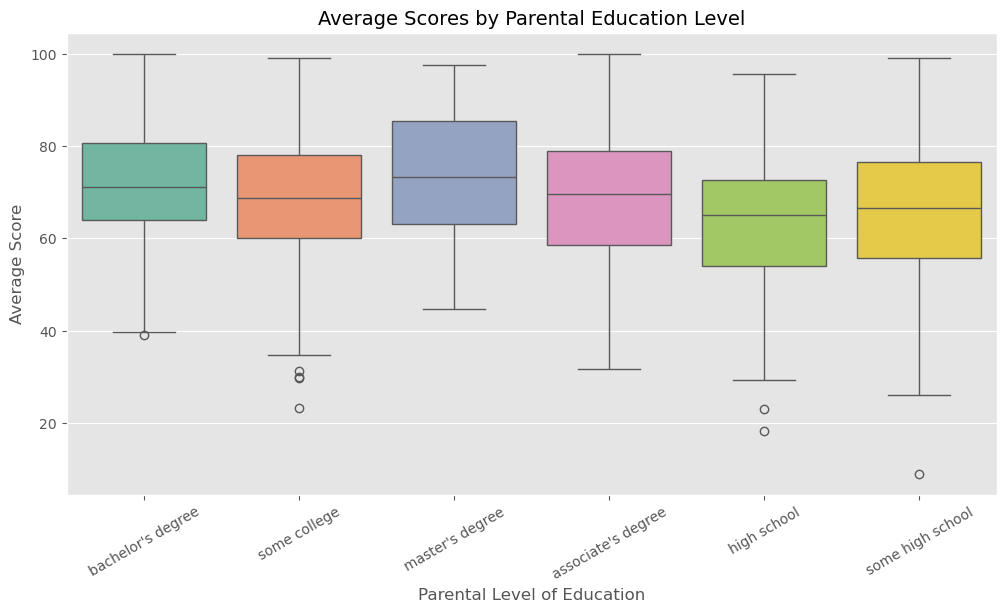

In [85]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='parental level of education',
    y='average_score',
    data=df,
    palette='Set2'
)

plt.title("Average Scores by Parental Education Level", fontsize=14)
plt.xlabel("Parental Level of Education")
plt.ylabel("Average Score")
plt.xticks(rotation=30)

plt.show()

In [73]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


Insight

Students whose parents have Bachelor's and Master's degrees generally achieve higher academic scores.

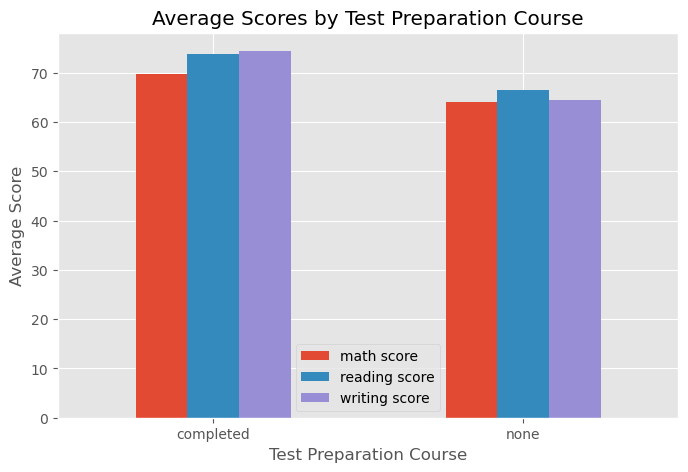

In [87]:
prep = df.groupby('test preparation course')[
    ['math score','reading score','writing score']
].mean()

prep.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Scores by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.show()

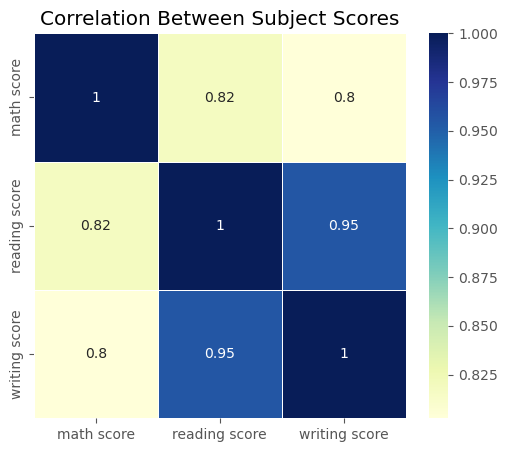

In [88]:
corr = df[['math score','reading score','writing score']].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title("Correlation Between Subject Scores")

plt.show()

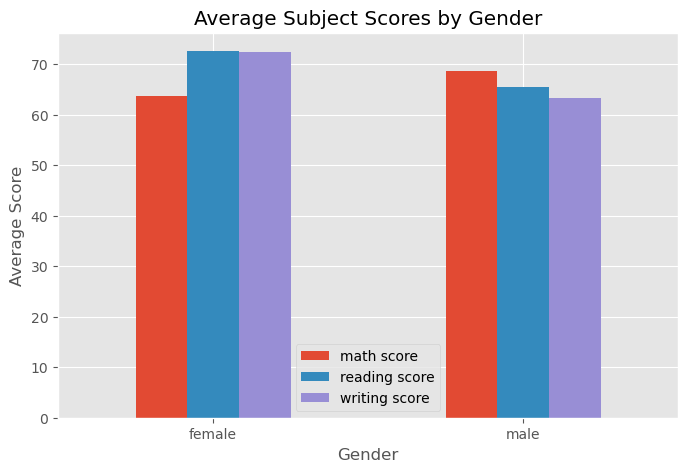

In [89]:
gender_scores = df.groupby('gender')[
    ['math score','reading score','writing score']
].mean()

gender_scores.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Subject Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.show()

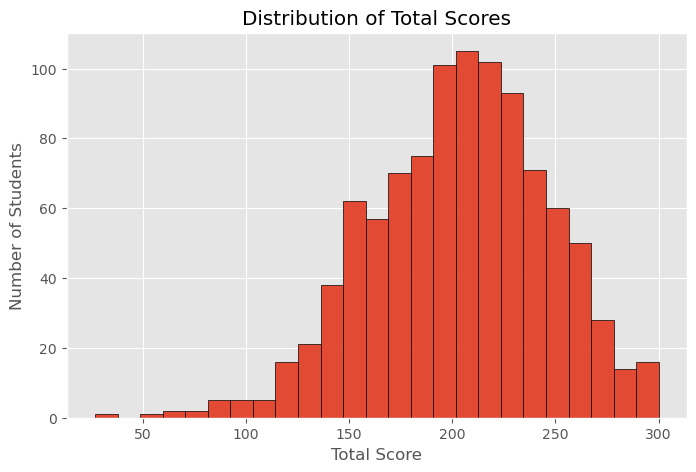

In [90]:
plt.figure(figsize=(8,5))

plt.hist(
    df['total_score'],
    bins=25,
    edgecolor='black'
)

plt.title("Distribution of Total Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")

plt.show()

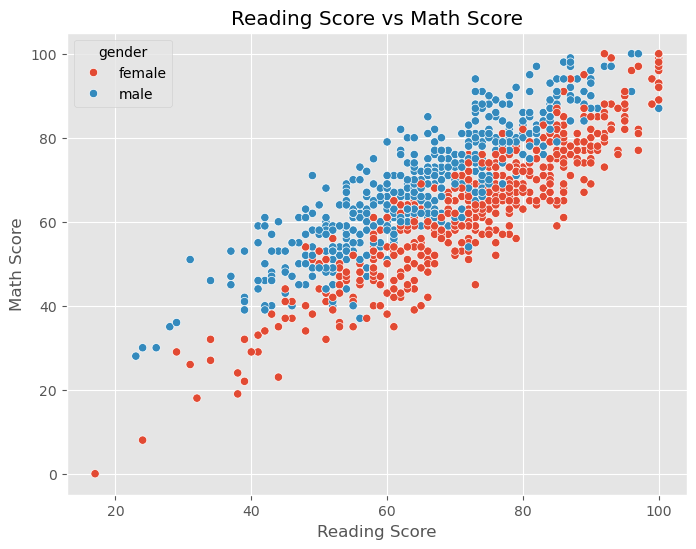

In [91]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='reading score',
    y='math score',
    data=df,
    hue='gender'
)

plt.title("Reading Score vs Math Score")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")

plt.show()

In [92]:
at_risk = df[
    (df['math score'] < 50) |
    (df['reading score'] < 50) |
    (df['writing score'] < 50)
]

print("Total Students:", len(df))
print("At-Risk Students:", len(at_risk))

print("Percentage:",
      round(len(at_risk)/len(df)*100,2),"%")

Total Students: 1000
At-Risk Students: 188
Percentage: 18.8 %


In [93]:
risk_gender = (
    at_risk.groupby('gender')
    .size()
    .reset_index(name='Count')
)

risk_gender

,gender,Count
0,female,89
1,male,99


C:\Users\HP\AppData\Local\Temp\ipykernel_7432\1807197700.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




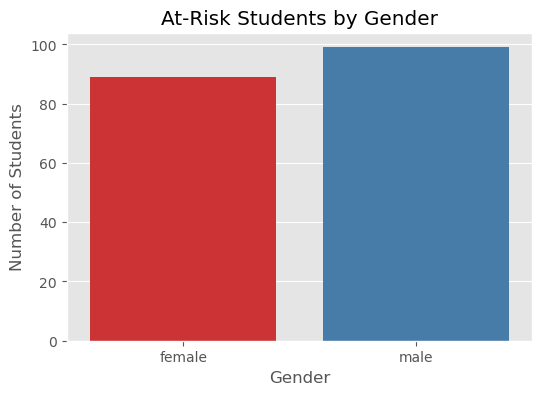

In [94]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=risk_gender,
    x='gender',
    y='Count',
    palette='Set1'
)

plt.title("At-Risk Students by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.show()

In [95]:
risk_parent = (
    at_risk.groupby('parental level of education')
    .size()
    .sort_values(ascending=False)
)

risk_parent

parental level of education
high school           49
some high school      46
some college          38
associate's degree    33
bachelor's degree     16
master's degree        6
dtype: int64

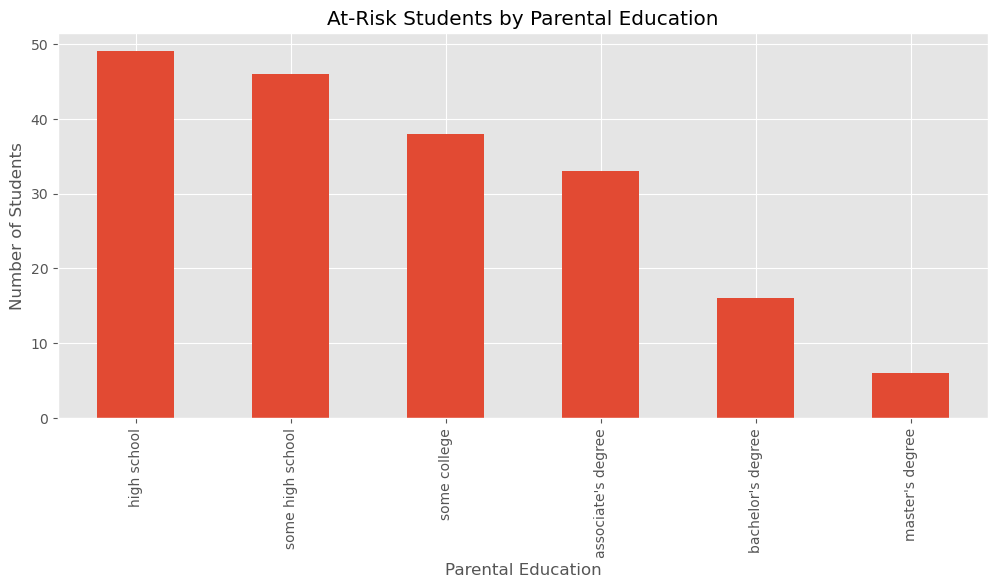

In [96]:
plt.figure(figsize=(12,5))

risk_parent.plot(kind='bar')

plt.title("At-Risk Students by Parental Education")
plt.xlabel("Parental Education")
plt.ylabel("Number of Students")

plt.show()

In [97]:
risk_test = (
    at_risk.groupby('test preparation course')
    .size()
)

risk_test

test preparation course
completed     36
none         152
dtype: int64

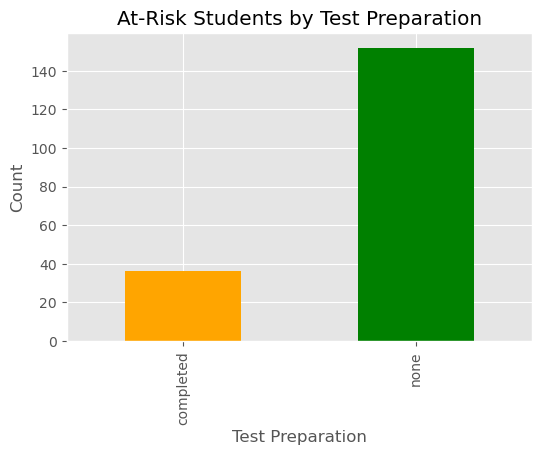

In [98]:
plt.figure(figsize=(6,4))

risk_test.plot(kind='bar', color=['orange','green'])

plt.title("At-Risk Students by Test Preparation")
plt.xlabel("Test Preparation")
plt.ylabel("Count")

plt.show()